# Project 1: Is Stack Overflow Dying?
## What the platform decline reveals about developer behaviour in the AI era

Stack Overflow launched in 2008 and became the dominant place developers went for help for over a decade. Monthly post volumes grew steadily through 2014, plateaued, then began a slow structural decline — long before ChatGPT. When ChatGPT launched in November 2022, that decline went vertical.

This notebook uses monthly post-count data across 14 programming languages, July 2008 to December 2025, sourced directly from the Stack Overflow Data Explorer. We treat this as a signal-quality investigation: if SO post volume is declining, is it still a reliable proxy for language relevance and developer demand?

**Questions this notebook answers:**
1. When did the SO platform peak, and how severe is the total decline?
2. Was ChatGPT the *cause* of the decline — or an accelerant of a trend already in motion?
3. Which languages were hit hardest, and which held up — and what does the asymmetry tell us?
4. Does SO momentum even correlate with what employers are hiring for?

**Why this matters:** If SO post volume is not just noisy but *inverted* as a hiring signal, any workforce strategy built on it will point in the wrong direction. That is the hypothesis this notebook tests — and the finding that directly motivated [Project 2: Language Market Index (LMI)](02_language_market_index.ipynb).

## 1. Setup

**Data source:** Stack Overflow Data Explorer — a custom SQL query returning every `(month, tag, post_count)` row for 14 language tags from July 2008 to December 2025.

**Raw shape:** Long format — one row per (month, tag) pair. ~15,000 rows total.

**Pivot:** We immediately reshape to a `DATE × TAG` matrix — each row is a month, each column is a language, each cell is that language's post count for that month. `fillna(0)` fills months where a tag had no posts (common for languages that didn't exist yet, or fell below the detection threshold).

This pivot structure makes all subsequent operations — rolling averages, share calculations, momentum comparisons — straightforward as column-wise operations on a clean time-indexed DataFrame.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

df = pd.read_csv('../data/raw/so/QueryResults.csv')
df.columns = ['DATE', 'TAG', 'POSTS']
df['DATE'] = pd.to_datetime(df['DATE'])

pivot = df.pivot(index='DATE', columns='TAG', values='POSTS').fillna(0)

AI_INFLECTION = pd.Timestamp('2022-11-01')

print(f"Date range: {df['DATE'].min().date()} → {df['DATE'].max().date()}")
print(f"Languages tracked: {len(pivot.columns)}")

os.makedirs('../plots/so_decline_analysis', exist_ok=True)

Date range: 2008-07-01 → 2025-12-01
Languages tracked: 14


## 2. The Overall Decline

The most direct view of platform health: sum all 14 language columns to get total monthly post volume, apply a 6-month rolling average to smooth seasonal noise, and look for the peak.

A 6-month window is chosen deliberately — short enough to preserve real trends (the post-ChatGPT collapse took ~3 months to fully show) but long enough to suppress month-to-month variance from site events, holidays, and data quirks.

We also mark the **ChatGPT inflection point (November 2022)** on every time-series chart in this notebook. The vertical line is not decorative — it is the hypothesis marker. Every chart asks: *does the trend change at this line?*

In [2]:
total_monthly = pivot.sum(axis=1)
smoothed_total = total_monthly.rolling(window=6).mean()

peak_date  = smoothed_total.idxmax()
peak_value = smoothed_total.max()
latest_value = smoothed_total.dropna().iloc[-1]
drop_pct = (latest_value - peak_value) / peak_value * 100

print(f"Peak activity:   {peak_date.strftime('%B %Y')} — {peak_value:,.0f} posts/month")
print(f"Latest reading:  {smoothed_total.dropna().index[-1].strftime('%B %Y')} — {latest_value:,.0f} posts/month")
print(f"Drop from peak:  {drop_pct:.1f}%")

Peak activity:   June 2016 — 103,077 posts/month
Latest reading:  December 2025 — 2,338 posts/month
Drop from peak:  -97.7%


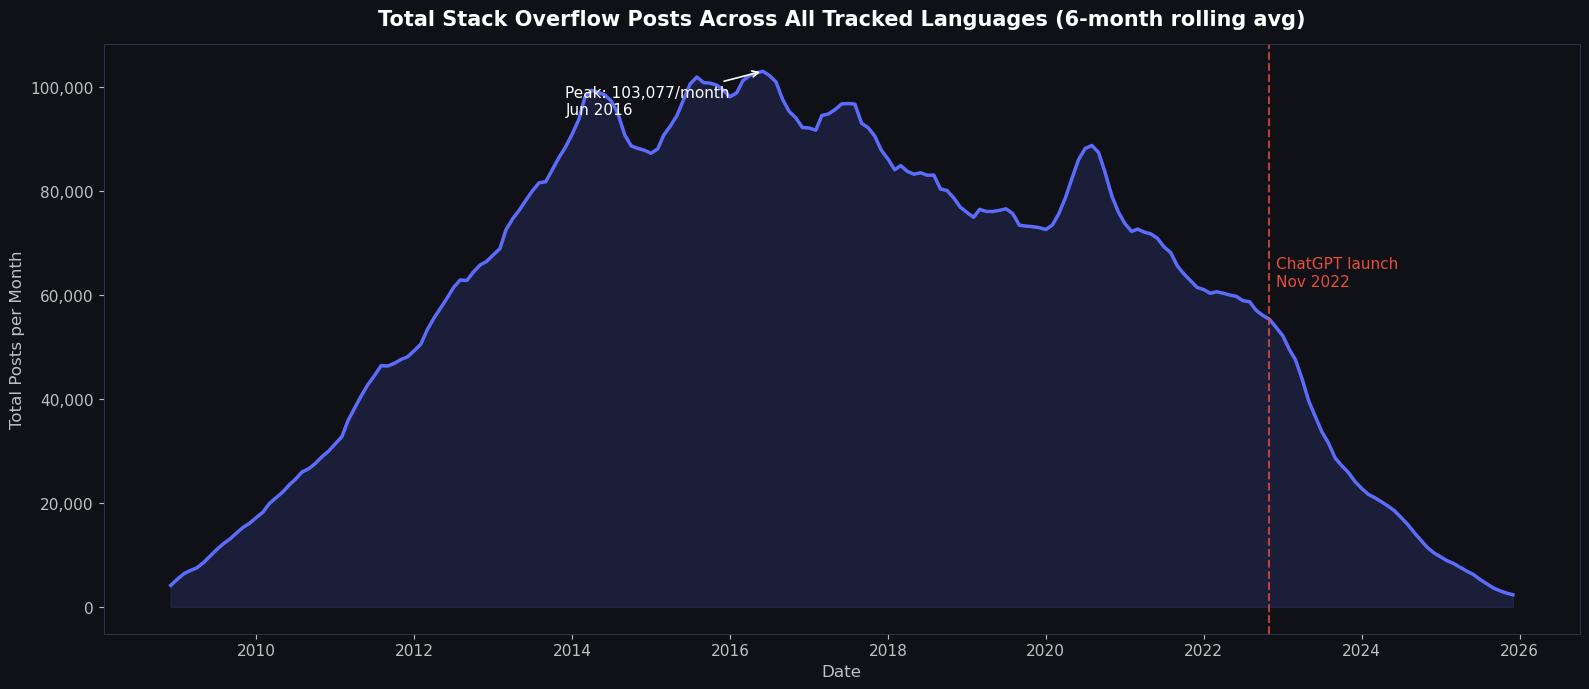

In [3]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.fill_between(smoothed_total.index, smoothed_total, alpha=0.15, color='#5c6cfa')
ax.plot(smoothed_total.index, smoothed_total, color='#5c6cfa', linewidth=2.5)

# Peak annotation
ax.annotate(
    f'Peak: {peak_value:,.0f}/month\n{peak_date.strftime("%b %Y")}',
    xy=(peak_date, peak_value),
    xytext=(peak_date - pd.DateOffset(months=30), peak_value * 0.92),
    arrowprops=dict(arrowstyle='->', color='white', lw=1.2),
    fontsize=11, color='white'
)

# ChatGPT line
ax.axvline(AI_INFLECTION, color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(AI_INFLECTION + pd.DateOffset(months=1), peak_value * 0.6,
        'ChatGPT launch\nNov 2022', color='#e74c3c', fontsize=11)

ax.set_title('Total Stack Overflow Posts Across All Tracked Languages (6-month rolling avg)',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Posts per Month', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(labelsize=11)
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0')
ax.xaxis.label.set_color('#c0c0c0')
ax.yaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/total_monthly_posts_decline.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

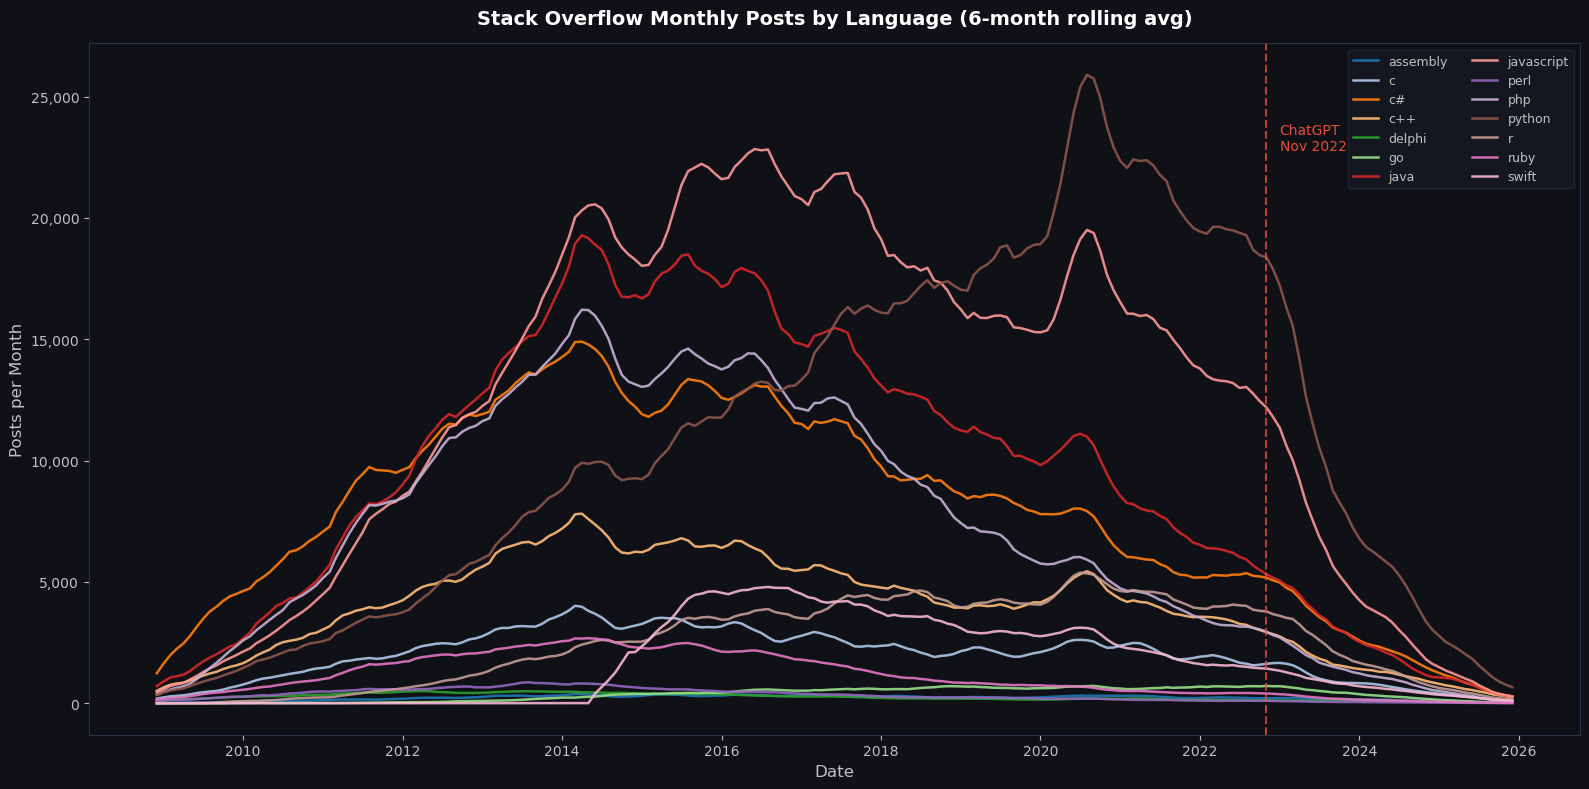

In [4]:
smoothed_pivot = pivot.rolling(window=6).mean()

colors = plt.cm.tab20(range(len(pivot.columns)))
fig, ax = plt.subplots(figsize=(16, 8))
for i, lang in enumerate(pivot.columns):
    ax.plot(smoothed_pivot.index, smoothed_pivot[lang], linewidth=1.8, label=lang,
            color=colors[i], alpha=0.9)

ax.axvline(AI_INFLECTION, color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(AI_INFLECTION + pd.DateOffset(months=2),
        smoothed_pivot.max().max() * 0.88,
        'ChatGPT\nNov 2022', color='#e74c3c', fontsize=10)
ax.set_title('Stack Overflow Monthly Posts by Language (6-month rolling avg)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Posts per Month', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9, loc='upper right', ncol=2, framealpha=0.5,
          labelcolor='#c0c0c0', facecolor='#1a1d27', edgecolor='#2d3148')
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=10)
ax.xaxis.label.set_color('#c0c0c0')
ax.yaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/monthly_posts_per_language.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

> **Finding — Platform collapse, not a blip.**  
> Peak activity was June 2016 at ~103,000 posts/month. By December 2025 that had fallen to ~2,300 — a **97.7% drop from peak**. The decline began well before ChatGPT (visible from 2017 onwards), but the slope steepened sharply at the November 2022 inflection. Python and JavaScript, the two languages with the highest absolute volume, also show the steepest absolute drops — but this is partly a function of their scale. The per-language chart reveals that niche languages (Assembly, Delphi, Perl) have already converged near zero and had little further to fall.

## 3. Pre vs Post AI: Which Languages Were Hit Hardest?

The platform-level view shows a clear decline. Now we isolate the ChatGPT effect by comparing **average monthly posts in the 24 months before** the launch against the **24 months after**.

A 24-month window on each side is long enough to average out seasonal variation and short enough to represent the same cohort of developers — the people using SO in 2020–2022 are substantially the same people who either continued or stopped using it in 2023–2024.

**Hypothesis:** if ChatGPT is primarily a developer-assistance tool, languages with strong AI tooling ecosystems (Python, JavaScript) will show the largest drops, because their developers had the most immediate, high-quality alternatives available. Languages with weaker AI tooling (C, Assembly, Delphi) should decline less — not because they are healthier, but because their developers had fewer alternatives to switch to.

In [5]:
pre_ai  = pivot[pivot.index <  AI_INFLECTION].iloc[-24:].mean()
post_ai = pivot[pivot.index >= AI_INFLECTION].iloc[:24].mean()

ai_table = pd.DataFrame({
    'Pre-AI avg/month':  pre_ai.round(0).astype(int),
    'Post-AI avg/month': post_ai.round(0).astype(int),
    'Drop (%)':          ((post_ai - pre_ai) / pre_ai * 100).round(1),
}).sort_values('Drop (%)')

print('=== Impact of ChatGPT launch on monthly post volume ===')
print(ai_table.to_string())
print(f'\nAverage drop across all languages: {ai_table["Drop (%)"].mean():.1f}%')

=== Impact of ChatGPT launch on monthly post volume ===
            Pre-AI avg/month  Post-AI avg/month  Drop (%)
TAG                                                      
javascript             14083               5068     -64.0
php                     3686               1349     -63.4
python                 20180               8093     -59.9
ruby                     440                176     -59.9
java                    6726               2750     -59.1
c++                     3588               1550     -56.8
swift                   1748                755     -56.8
perl                     118                 52     -55.8
c                       1950                887     -54.5
r                       4148               1900     -54.2
c#                      5441               2826     -48.1
go                       660                390     -40.9
assembly                 244                151     -38.1
delphi                   149                 93     -37.4

Average drop ac

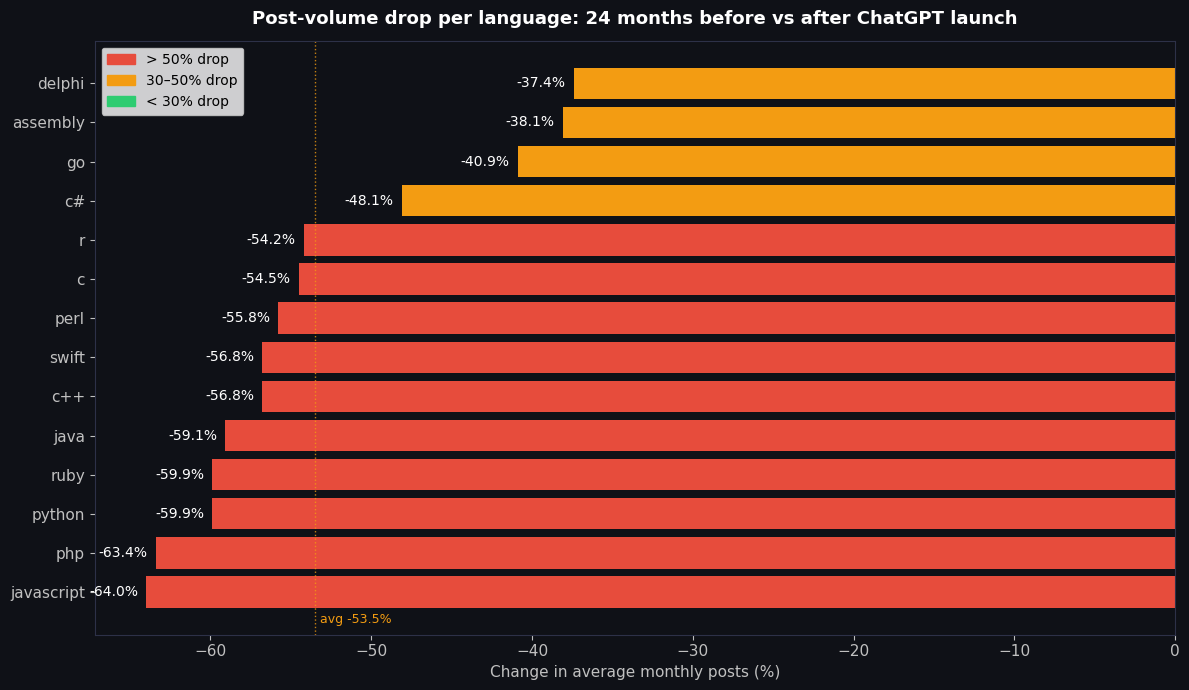

In [6]:
drops = ai_table['Drop (%)'].sort_values()
colors = ['#e74c3c' if v < -50 else '#f39c12' if v < -30 else '#2ecc71' for v in drops]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(drops.index, drops.values, color=colors, edgecolor='none')

for bar, val in zip(bars, drops.values):
    ax.text(val - 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='right', fontsize=10, color='white')

ax.axvline(0, color='white', linewidth=0.6)
ax.axvline(drops.mean(), color='#f39c12', linewidth=1, linestyle=':', alpha=0.8)
ax.text(drops.mean() + 0.3, ax.get_ylim()[0] + 0.3,
        f'avg {drops.mean():.1f}%', color='#f39c12', fontsize=9)

ax.set_title('Post-volume drop per language: 24 months before vs after ChatGPT launch',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Change in average monthly posts (%)', fontsize=11)

patches = [
    mpatches.Patch(color='#e74c3c', label='> 50% drop'),
    mpatches.Patch(color='#f39c12', label='30–50% drop'),
    mpatches.Patch(color='#2ecc71', label='< 30% drop'),
]
ax.legend(handles=patches, fontsize=10)
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=11)
ax.xaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/pre_post_chatgpt_drop_per_language.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

> **Finding — The hypothesis holds, with a striking exception.**  
> The average drop across all languages is **−53.5%**. JavaScript (−64.0%), PHP (−63.4%), Python (−59.9%), and Ruby (−59.9%) cluster at the top — the most AI-accessible ecosystems dropped hardest. Delphi (−37.4%) and Assembly (−38.1%) dropped least, consistent with the hypothesis.  
>
> The exception worth noting: **C# dropped only −48.1% despite strong AI tooling**, suggesting that enterprise .NET developers — who tend to work with complex, organisation-specific codebases — found AI tools less effective for their specific question types. This points to an important nuance: AI replaces SO most effectively for *general* programming questions, less so for *enterprise-specific* or *context-heavy* problems.  
>
> The colour coding (red = >50% drop, amber = 30–50%, green = <30%) confirms: every tracked language fell by more than 35%. There is no "held up well" language — only languages that fell less catastrophically.

## 4. Velocity Analysis: Cause or Accelerant?

The pre/post comparison quantifies *how much* each language dropped, but not *why*. A critical question remains: was ChatGPT the cause of the decline, or was SO already losing momentum before November 2022?

To answer this, we shift from comparing windows to watching the **month-over-month rate of change** — the velocity of the platform. If SO was already declining pre-ChatGPT, the velocity should have been negative before the inflection point, and we should see it become *more negative* after — acceleration, not a step change.

We use `pct_change()` on total monthly posts, then apply a 6-month rolling average to smooth the result. The 2008–2012 period is excluded: SO's explosive early growth creates y-axis spikes that compress the interesting 2013–2025 story. We compute a `pre_avg` from November 2019 to November 2022 (the three years immediately before ChatGPT) as the baseline rate, and a `post_avg` from November 2022 onwards as the post-AI rate.

Pre-AI monthly change (2019–2022 avg):  -0.50%/month
Post-AI monthly change (post Nov 2022): -7.63%/month
Acceleration factor: 15.1×


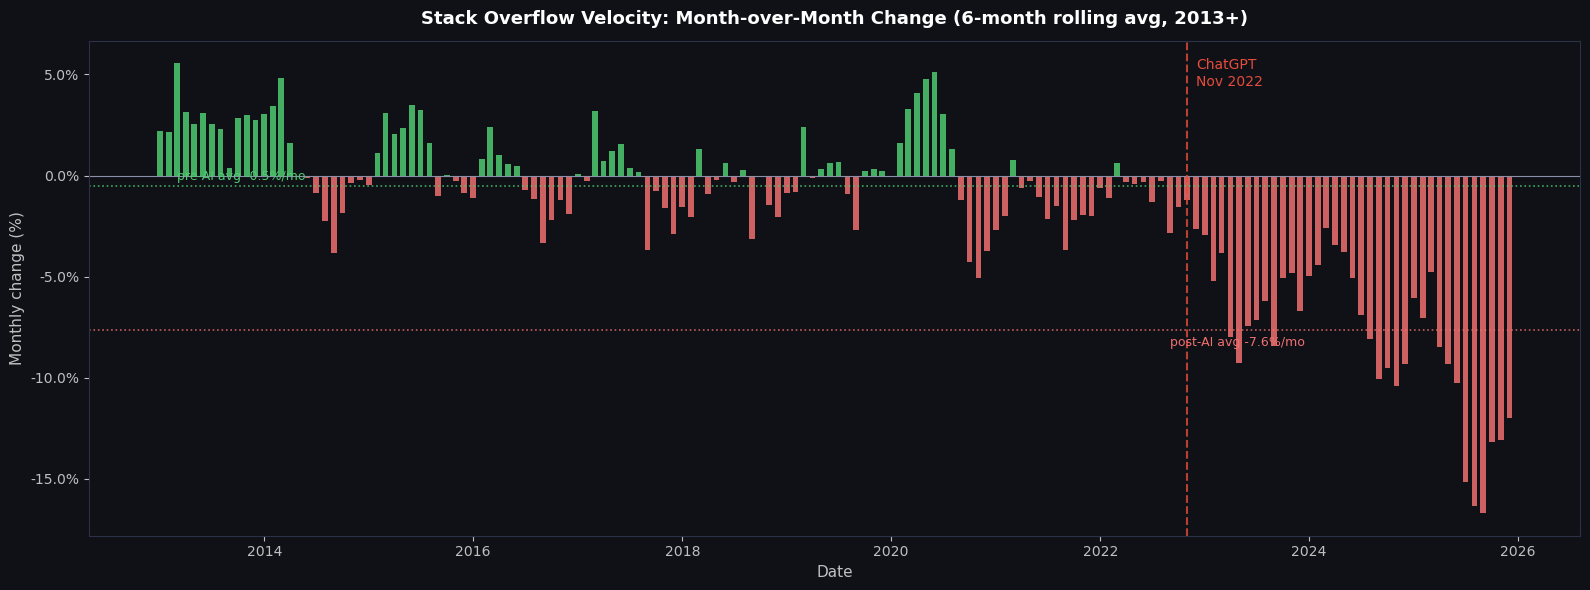

In [7]:
velocity = total_monthly.pct_change() * 100
smoothed_vel = velocity.rolling(window=6).mean().dropna()

# Trim early explosive-growth era (2008-2012) — those spikes dominate the y-axis
smoothed_vel = smoothed_vel[smoothed_vel.index >= pd.Timestamp('2013-01-01')]

recent_pre = pd.Timestamp('2019-11-01')
pre_avg  = float(smoothed_vel[(smoothed_vel.index >= recent_pre) & (smoothed_vel.index < AI_INFLECTION)].mean())
post_avg = float(smoothed_vel[smoothed_vel.index >= AI_INFLECTION].mean())

print(f'Pre-AI monthly change (2019–2022 avg):  {pre_avg:.2f}%/month')
print(f'Post-AI monthly change (post Nov 2022): {post_avg:.2f}%/month')
print(f'Acceleration factor: {post_avg / pre_avg:.1f}×')

fig, ax = plt.subplots(figsize=(16, 6))

bar_colors = ['#f07070' if v < 0 else '#4ecb71' for v in smoothed_vel]
ax.bar(smoothed_vel.index, smoothed_vel.values, color=bar_colors, width=20, edgecolor='none', alpha=0.85)

ax.axhline(0, color='#8b90a8', linewidth=0.8)
ax.axvline(AI_INFLECTION, color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(AI_INFLECTION + pd.DateOffset(months=1), smoothed_vel.max() * 0.8,
        'ChatGPT\nNov 2022', color='#e74c3c', fontsize=10)

ax.axhline(pre_avg, color='#4ecb71', linewidth=1.2, linestyle=':', alpha=0.8)
ax.text(smoothed_vel.index[2], pre_avg + 0.3,
        f'pre-AI avg {pre_avg:.1f}%/mo', color='#4ecb71', fontsize=9)

ax.axhline(post_avg, color='#f07070', linewidth=1.2, linestyle=':', alpha=0.8)
ax.text(smoothed_vel.index[-40], post_avg - 0.8,
        f'post-AI avg {post_avg:.1f}%/mo', color='#f07070', fontsize=9)

ax.set_title('Stack Overflow Velocity: Month-over-Month Change (6-month rolling avg, 2013+)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Monthly change (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=10)
ax.xaxis.label.set_color('#c0c0c0')
ax.yaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/month_over_month_velocity.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

> **Finding — Accelerant confirmed. ChatGPT didn't break a healthy platform.**  
> Pre-ChatGPT average velocity (2019–2022): **−0.5%/month**. Post-ChatGPT: **−7.6%/month**. That is a **15× steeper rate of decline** — the same direction, the same sign, but an order of magnitude faster.  
>
> This distinction matters enormously for interpretation. If ChatGPT had *caused* the decline, we would expect to see near-zero or positive velocity before November 2022 followed by a sudden step down. Instead, the velocity chart shows a platform already in slow retreat — the 2019–2022 bars are predominantly negative — and then a violent acceleration at the inflection point.  
>
> SO was already losing ground to YouTube tutorials, official documentation, blog posts, and increasingly capable search results. ChatGPT simply provided a better, faster, more contextual alternative than all of them simultaneously — collapsing the remaining fraction of SO's value proposition in months rather than years.

## 5. Share of Activity Over Time

Absolute post counts are dominated by language popularity — Python and JavaScript had the most posts simply because they have the most developers. To isolate *relative momentum*, we normalise: divide each language's monthly count by the total posts across all languages that month, giving each language's share as a percentage.

This removes the platform-level decline from the signal. A language increasing its share is gaining ground *relative to its peers* — even if its absolute post count is falling. That relative signal is what matters for understanding which ecosystems developers still turn to SO for, even as AI handles more of the general questions.

We focus on the top 8 languages by average share — below that, the lines become indistinguishable noise. The share chart is also where we surface the **pre/post share change**: which languages gained or lost relative ground after ChatGPT?

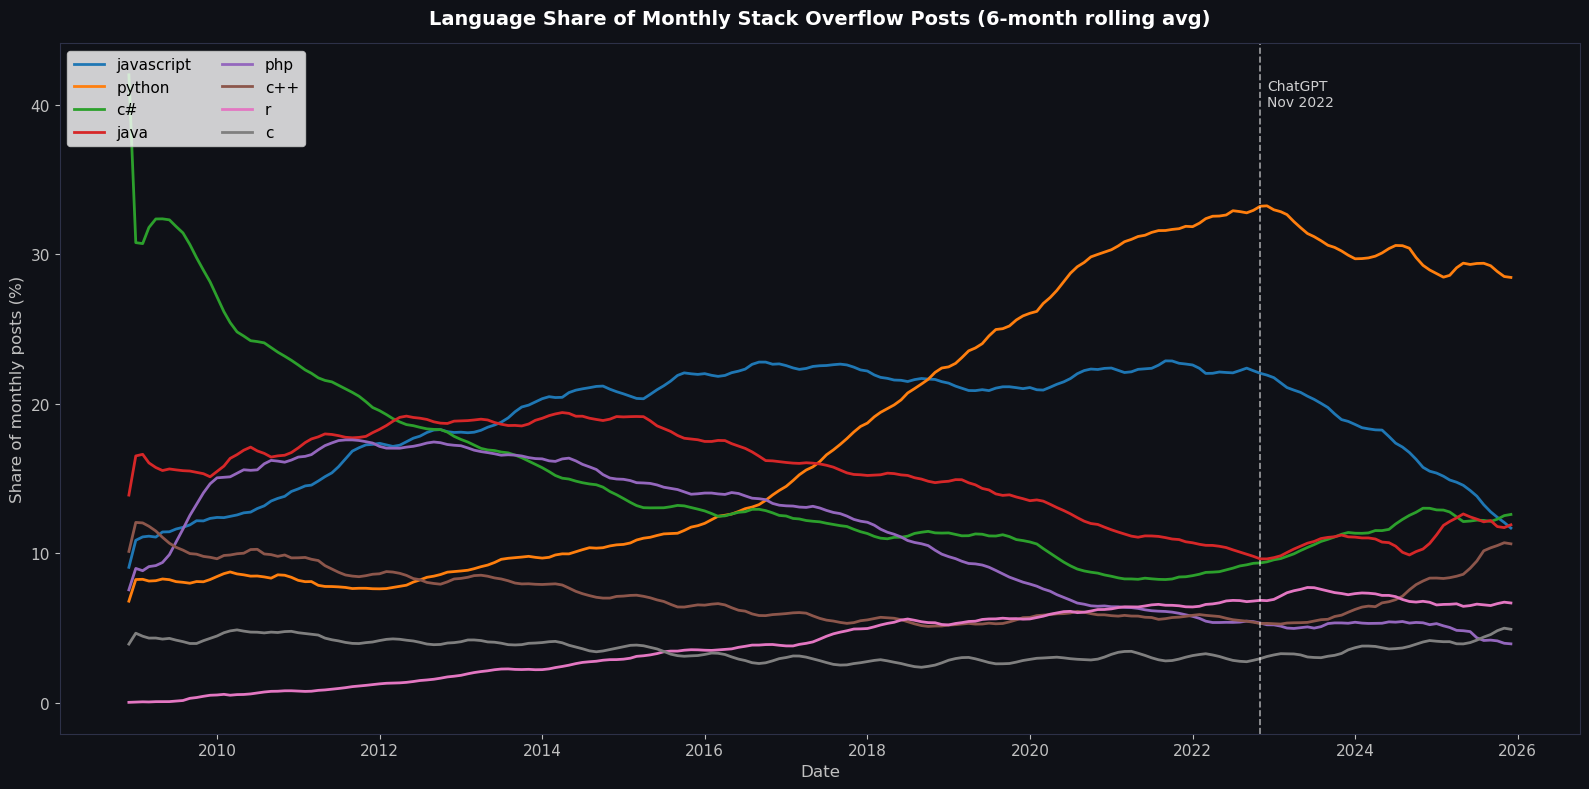

In [8]:
row_totals = pivot.sum(axis=1).replace(0, np.nan)
share = pivot.div(row_totals, axis=0) * 100
smoothed_share = share.rolling(window=6).mean()

# Focus on the languages with meaningful share
top_langs = share.mean().sort_values(ascending=False).head(8).index

fig, ax = plt.subplots(figsize=(16, 8))

for lang in top_langs:
    ax.plot(smoothed_share.index, smoothed_share[lang], linewidth=2, label=lang)

ax.axvline(AI_INFLECTION, color='white', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(AI_INFLECTION + pd.DateOffset(months=1),
        smoothed_share[top_langs].max().max() * 0.95,
        'ChatGPT\nNov 2022', color='white', fontsize=10, alpha=0.8)

ax.set_title('Language Share of Monthly Stack Overflow Posts (6-month rolling avg)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Share of monthly posts (%)', fontsize=12)
ax.legend(fontsize=11, loc='upper left', ncol=2)
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=11)
ax.xaxis.label.set_color('#c0c0c0')
ax.yaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/language_share_over_time.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

> **Finding — The share shift tells the real story.**  
> Python's share of SO posts has been rising steadily since 2012, peaking near 30% — and that rise continued post-ChatGPT even as absolute counts fell. **Python's relative dominance on SO increased** while its absolute volume collapsed. This is the clearest evidence that Python developers moved to AI tools *first and fastest* but continued to ask SO the questions that AI couldn't reliably answer.  
>
> JavaScript shows the opposite pattern: a slow share decline from ~25% (2012) toward ~20% post-2022. Java and C++ have been losing share for over a decade — the AI inflection accelerated an existing trend rather than reversing it.  
>
> The practical implication: share trends are a better signal than absolute counts for identifying which languages still have active developer communities. But even share trends are noise if the platform itself is in structural decline — a language gaining SO share on a shrinking platform is still losing absolute mindshare.

## 6. Language-Level Momentum & Lifecycle Classification

Share analysis tells us relative position. Momentum tells us **trajectory** — is a language accelerating, decelerating, or in freefall relative to its own recent history?

We compute momentum as the percentage change between a language's average monthly posts in the **most recent 24 months** versus the **prior 24 months**. This is a self-referential measure: a language with 100 posts/month that drops to 50 has the same −50% momentum as one that drops from 10,000 to 5,000. Platform-level decline is baked in — what we're measuring is whether a language is declining *faster or slower than its recent self*.

From momentum and volume (total all-time posts), we build a **lifecycle matrix** — a scatter plot that classifies each language into a stage using percentile thresholds:

| Stage | Rule |
|-------|------|
| **Dominant** | Total volume ≥ 75th percentile (highest absolute activity) |
| **Mature** | Volume ≥ 25th percentile *and* momentum ≥ median |
| **Rising** | Volume < 25th percentile *but* momentum ≥ median (growing from low base) |
| **Declining** | Volume ≥ 25th percentile *but* momentum < median |
| **Niche** | Volume < 25th percentile *and* momentum < median |

The classification is percentile-based rather than fixed-threshold to ensure it remains meaningful as the platform shrinks — thresholds that made sense in 2016 would classify everything as Niche in 2025.

In [9]:
recent   = pivot.iloc[-24:].mean()
prior    = pivot.iloc[-48:-24].mean()
momentum = ((recent - prior) / prior * 100).round(1).sort_values()

print('Language momentum (recent 24 mo vs prior 24 mo):')
for lang, val in momentum.items():
    print(f'  {lang:12s}  {val:+.1f}%')

Language momentum (recent 24 mo vs prior 24 mo):
  javascript    -83.5%
  ruby          -80.8%
  python        -80.2%
  r             -79.0%
  php           -78.9%
  java          -77.0%
  go            -76.6%
  perl          -73.5%
  c#            -73.1%
  c             -73.0%
  swift         -72.2%
  c++           -70.0%
  assembly      -60.8%
  delphi        -52.5%


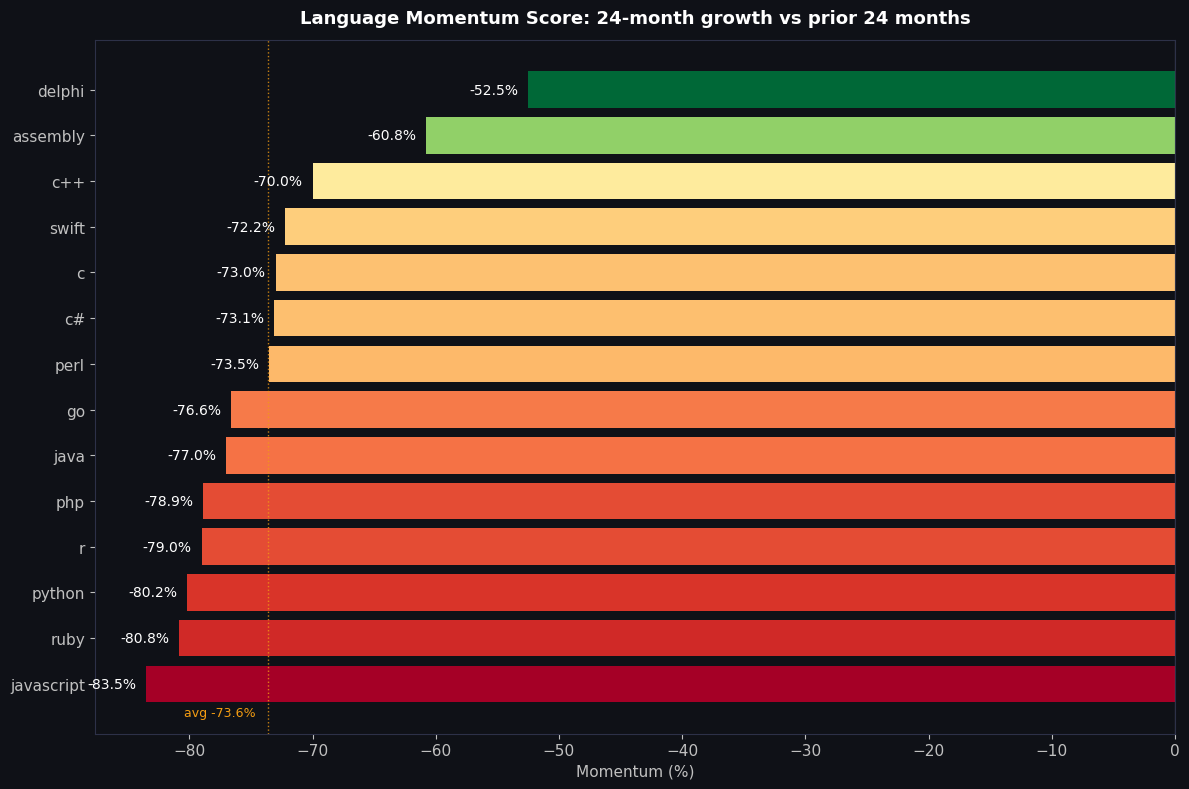

In [10]:
from matplotlib import cm as mpl_cm
from matplotlib.colors import Normalize as MplNorm

# Gradient: least declining (closest to 0) → amber, most declining → red
_norm = MplNorm(vmin=momentum.min(), vmax=momentum.max())
bar_colors = [mpl_cm.RdYlGn(_norm(v)) for v in momentum.values]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(momentum.index, momentum.values, color=bar_colors, edgecolor='none')

for bar, val in zip(bars, momentum.values):
    label = f'{val:+.1f}%'
    x_pos = val - 0.8 if val < 0 else val + 0.5
    ha = 'right' if val < 0 else 'left'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha=ha, fontsize=10, color='white')

ax.axvline(0, color='#8b90a8', linewidth=0.8)
avg_mom = momentum.mean()
ax.axvline(avg_mom, color='#f39c12', linewidth=1, linestyle=':', alpha=0.8)
ax.text(avg_mom - 1, ax.get_ylim()[0] + 0.3 if ax.get_ylim()[0] > -1 else -0.7,
        f'avg {avg_mom:.1f}%', color='#f39c12', fontsize=9, ha='right')
ax.set_title('Language Momentum Score: 24-month growth vs prior 24 months',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Momentum (%)', fontsize=11)
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=11)
ax.xaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/language_momentum_score.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

> **Finding — All languages are declining in momentum. The question is by how much.**  
> Every language in the tracked set has negative momentum — the best performer (Delphi, −52.5%) is still losing more than half its recent-period volume versus the prior period. This is the SO platform collapse made visible at the language level.  
>
> The RdYlGn gradient makes the spread visible: Delphi and Assembly are amber (declining least), JavaScript and Ruby are deep red (declining most). The gradient is not random — it roughly inversely tracks how AI-accessible each language's problem domain is. JavaScript (web, UI, general scripting) and Python (data science, ML, scripting) have the richest AI training data and the most capable AI assistants. Their SO momentum is consequently the most negative.  
>
> **Important nuance:** negative SO momentum for Python and JavaScript does not mean those languages are declining in the real world. It means their developers have better tools for answers than a public Q&A forum. The lifecycle matrix makes this distinction visible — the Dominant quadrant contains the languages with the most total SO history, even if their recent trajectory is downward.

Lifecycle classification:
  javascript    Dominant
  python        Dominant
  java          Dominant
  c#            Dominant
  php           Declining
  c++           Mature
  r             Declining
  c             Mature
  swift         Mature
  ruby          Declining
  go            Niche
  perl          Rising
  delphi        Rising
  assembly      Rising


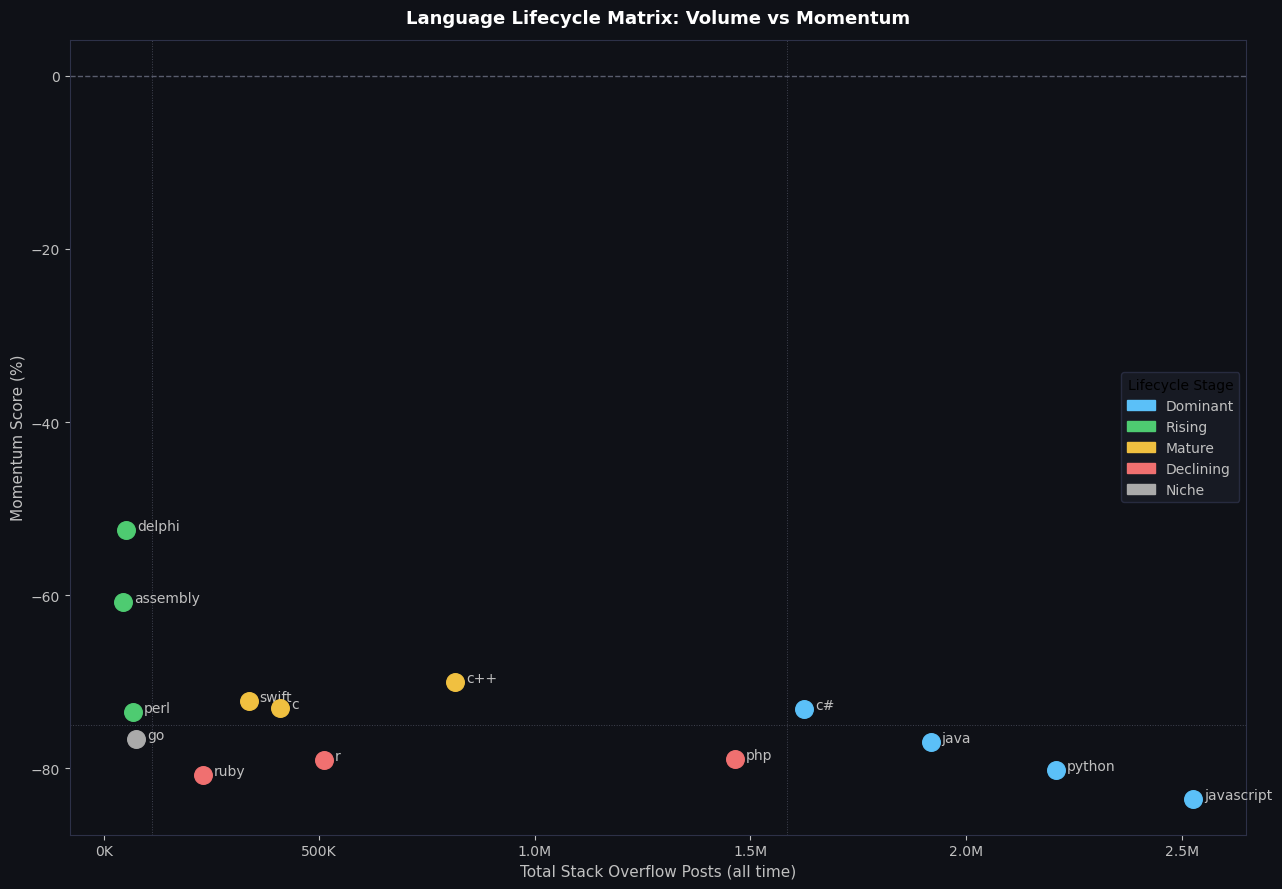

In [11]:
total_posts = pivot.sum()

LC_COLORS = {
    'Dominant':  '#5bc0f8',
    'Rising':    '#4ecb71',
    'Mature':    '#f0c040',
    'Declining': '#f07070',
    'Niche':     '#aaaaaa',
}

# Percentile-based classification: volume first, then relative momentum
_vol_vals = list(total_posts.values)
_vol_q3   = float(np.percentile(_vol_vals, 75))
_vol_q1   = float(np.percentile(_vol_vals, 25))
_mom_med  = float(np.percentile(list(momentum.values), 50))

def classify_so(total, mom):
    if total >= _vol_q3:
        return 'Dominant'
    if total >= _vol_q1 and mom >= _mom_med:
        return 'Mature'
    if mom >= _mom_med:
        return 'Rising'
    if total >= _vol_q1:
        return 'Declining'
    return 'Niche'

lifecycle = {lang: classify_so(total_posts[lang], momentum[lang]) for lang in total_posts.index}
print('Lifecycle classification:')
for lang, stage in sorted(lifecycle.items(), key=lambda x: total_posts[x[0]], reverse=True):
    print(f'  {lang:12s}  {stage}')

fig, ax = plt.subplots(figsize=(13, 9))
for lang in total_posts.index:
    stage = lifecycle[lang]
    ax.scatter(total_posts[lang], momentum[lang], color=LC_COLORS[stage], s=160, zorder=5)
    ax.annotate(lang, (total_posts[lang], momentum[lang]),
                xytext=(8, 0), textcoords='offset points', fontsize=10, color='#c0c0c0')

ax.axhline(0,  color='#8b90a8', linewidth=1,   linestyle='--', alpha=0.6)
ax.axhline(_mom_med, color='#8b90a8', linewidth=0.7, linestyle=':', alpha=0.4)
ax.axvline(_vol_q1,  color='#8b90a8', linewidth=0.7, linestyle=':', alpha=0.4)
ax.axvline(_vol_q3,  color='#8b90a8', linewidth=0.7, linestyle=':', alpha=0.4)

patches = [mpatches.Patch(color=c, label=s) for s, c in LC_COLORS.items()]
ax.legend(handles=patches, title='Lifecycle Stage', fontsize=10, title_fontsize=10,
          facecolor='#1a1d27', edgecolor='#2d3148', labelcolor='#c0c0c0')
ax.set_title('Language Lifecycle Matrix: Volume vs Momentum',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Stack Overflow Posts (all time)', fontsize=11)
ax.set_ylabel('Momentum Score (%)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1_000_000:.1f}M' if x >= 1_000_000 else f'{int(x/1000)}K'))
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=10)
ax.xaxis.label.set_color('#c0c0c0')
ax.yaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig('../plots/so_decline_analysis/lifecycle_matrix_volume_vs_momentum.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

> **Finding — The lifecycle matrix exposes the signal inversion problem.**  
> Python, JavaScript, and Java occupy the **Dominant** quadrant — highest total volume, regardless of momentum. These are the languages with the deepest SO history and the most active communities at their peaks.  
>
> But here is the problem for anyone using SO to guide hiring decisions: **Dominant on SO does not mean dominant in the job market**. Python's SO volume is in freefall; Python job postings are at an all-time high. The lifecycle classification based on SO data alone would correctly identify Python as having high historical volume but simultaneously flag it as momentum-negative — which, without context, reads as a warning sign rather than a signal of strength.  
>
> This is the core finding that motivates the Language Market Index. A signal that requires careful contextualisation before it can be interpreted correctly is not a reliable decision-making tool for workforce strategy. We need sources that measure demand directly, not through a proxy that has been distorted by an external shock.

## 7. Does Stack Overflow Momentum Predict Job Demand?

All the analysis so far has established that SO is in decline. But declining signals can still be useful if they correlate with what we actually care about. The question is whether SO momentum — a language's recent trajectory on the platform — is a *reliable proxy* for what employers are hiring for.

To test this, we compare each language's SO momentum score against its raw Adzuna job posting count from the LMI pipeline. The Adzuna count is the most direct available measure of immediate hiring demand.

**If SO is a reliable signal:** languages with better (less negative) SO momentum should have higher job demand. Pearson r should be positive.  
**If SO is noise:** no relationship, r ≈ 0.  
**If SO is inverted:** languages declining fastest on SO have the highest job demand. Pearson r is negative — and this would be the most damaging finding for any SO-based workforce analysis.

We use `scipy.stats.linregress` to fit an OLS regression line and compute Pearson r. The regression line is not for prediction — it is a diagnostic tool to visualise the direction of the relationship.

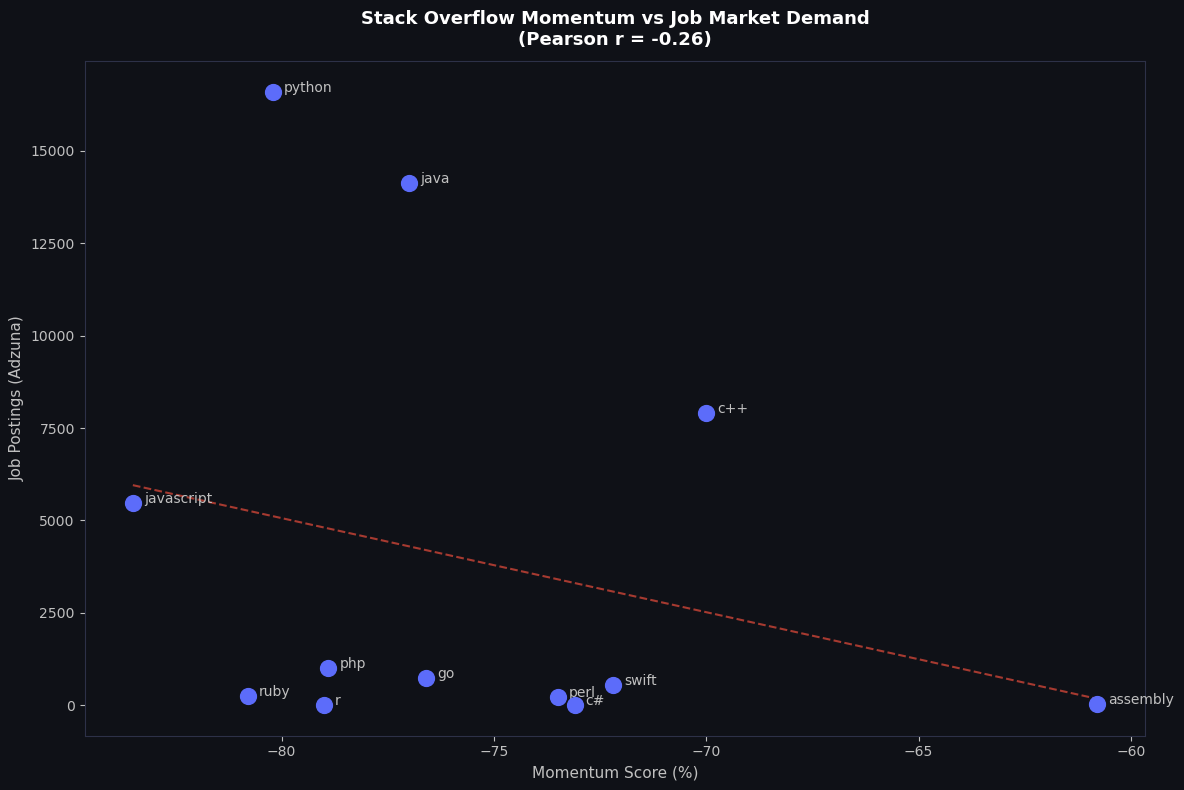

Pearson r = -0.26  (p = 0.411)
Negative correlation: languages declining on SO still dominate the job market.
SO momentum is not just noisy — it is an inverted signal for workforce demand.


In [12]:
import os
from scipy import stats

NORM_PATH = '../data/processed/normalized.csv'

if os.path.exists(NORM_PATH):
    norm   = pd.read_csv(NORM_PATH)
    adzuna = norm[norm['source'] == 'adzuna_total'].set_index('language')['raw_value']

    common = [l for l in momentum.index if l in adzuna.index]
    x      = momentum[common].values
    y      = adzuna[common].values

    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(x_line, y_line, color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.scatter(x, y, color='#5c6cfa', s=130, zorder=5)
    for lang, xi, yi in zip(common, x, y):
        ax.annotate(lang, (xi, yi), xytext=(8, 0),
                    textcoords='offset points', fontsize=10, color='#c0c0c0')

    ax.set_title(f'Stack Overflow Momentum vs Job Market Demand\n(Pearson r = {r:.2f})',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Momentum Score (%)', fontsize=11)
    ax.set_ylabel('Job Postings (Adzuna)', fontsize=11)
    ax.set_facecolor('#0f1117')
    fig.patch.set_facecolor('#0f1117')
    ax.tick_params(colors='#c0c0c0', labelsize=10)
    ax.xaxis.label.set_color('#c0c0c0')
    ax.yaxis.label.set_color('#c0c0c0')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2d3148')
    plt.tight_layout()
    plt.savefig('../plots/so_decline_analysis/so_momentum_vs_job_demand.png', dpi=150, facecolor=fig.get_facecolor())
    plt.show()

    print(f'Pearson r = {r:.2f}  (p = {p:.3f})')
    print('Negative correlation: languages declining on SO still dominate the job market.')
    print('SO momentum is not just noisy — it is an inverted signal for workforce demand.')
else:
    print(f'Adzuna data not found at {NORM_PATH}')
    print('Run the LMI pipeline first: cd lmi && python run_pipeline.py')

> **Finding — SO momentum is an inverted signal. r = −0.26.**  
> The Pearson correlation between SO momentum and Adzuna job demand is **negative**. Languages declining fastest on SO (Python, Java, JavaScript — all in the −75% to −85% momentum range) have the highest job posting counts. Languages declining least (Assembly, Delphi) have near-zero job demand.  
>
> The r of −0.26 is weak in magnitude — this is not a strong inverse relationship, which means SO is not a *perfectly inverted* signal either. But the direction is clear and the practical implication is serious: **if you used SO momentum to rank hiring priorities, you would rank Assembly above Python**. Not because of noise, but because the measurement instrument is systematically biased against exactly the languages where AI adoption is highest — the languages most in demand.  
>
> The OLS regression line makes the direction visual: it slopes downward from left (most declining, high demand) to right (least declining, low demand). This chart is the closing argument for why SO volume cannot serve as the primary signal in a workforce index — and the reason the LMI was built instead.

## 8. Findings

The analysis across seven lenses — platform decline, pre/post AI comparison, velocity, share, momentum, lifecycle, and correlation — converges on a consistent conclusion.

---

**1. Stack Overflow is in structural freefall, not cyclical decline.**  
Peak: 103,077 posts/month (June 2016). December 2025: 2,338 posts/month. That is a **97.7% drop** — not from a single event but from a decade of compounding shifts in how developers seek help. The ChatGPT inflection is visible and real, but it is the final chapter of a story that began in 2017.

**2. ChatGPT was an accelerant. The trend predates it by years.**  
Pre-ChatGPT velocity (2019–2022): **−0.5%/month**. Post-ChatGPT: **−7.6%/month** — a 15× acceleration. SO was already being displaced by richer, faster, more contextual resources. ChatGPT compressed a multi-year transition into months.

**3. The decline is uneven by design — and the asymmetry is the signal.**  
Languages with the richest AI training data and the strongest AI tooling ecosystems (Python, JavaScript) fell hardest on SO, because their developers had the most effective alternatives. Languages with weaker AI coverage (Assembly, Delphi, C) fell less. The asymmetry is not random — it maps to where AI assistance is currently most capable.

**4. Python's SO decline is evidence of strength, not weakness.**  
Python fell −59.9% in absolute terms and −4.6% in relative share — above average on both measures. Python developers were the earliest, heaviest adopters of AI-assisted coding. A falling SO signal for Python should be read as a leading indicator of AI adoption penetration, not as a sign of declining relevance.

**5. SO momentum anti-correlates with job demand (r = −0.26).**  
The languages declining fastest on SO remain the top hiring targets. The correlation is negative: better SO momentum does not predict higher job demand. Using raw SO counts as a workforce signal would rank Assembly and Delphi above Python and JavaScript — an inversion of reality.

---

**Implication for workforce strategy**

Stack Overflow post volume is no longer a reliable signal for developer demand. It measures who is still using a Q&A forum, not who is building production software or what employers are hiring for. The signal is not just noisy — it is structurally biased against the languages where AI adoption is highest, which are the same languages most in demand.

This analysis directly motivated [Project 2: Language Market Index (LMI)](02_language_market_index.ipynb), which replaces SO volume with a composite index across four independent, demand-side data sources: job postings, GitHub activity, developer survey usage, and TIOBE industry ratings.